In [1]:
using CSV
using DataFrames
using DelimitedFiles
using CairoMakie
using LsqFit

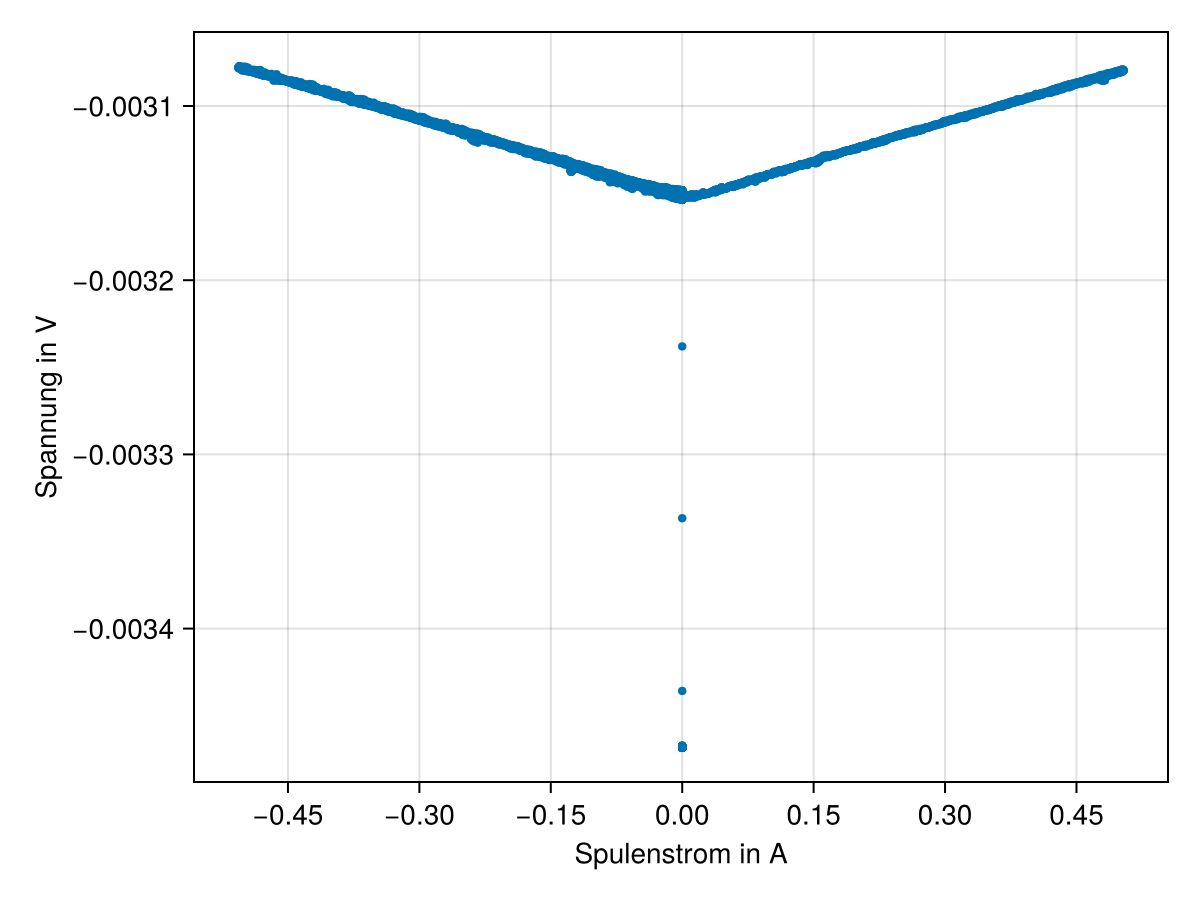

In [6]:
messung = readdlm("Hspule_strom_paralell", skipstart=2)

x = messung[:,1]
y = messung[:,2]

fig = Figure()
ax = Axis(fig[1,1], xlabel = "Spulenstrom in A", ylabel ="Spannung in V",
 xticks=LinearTicks(8))

scatter!(ax, x, y, markersize=6)
fig


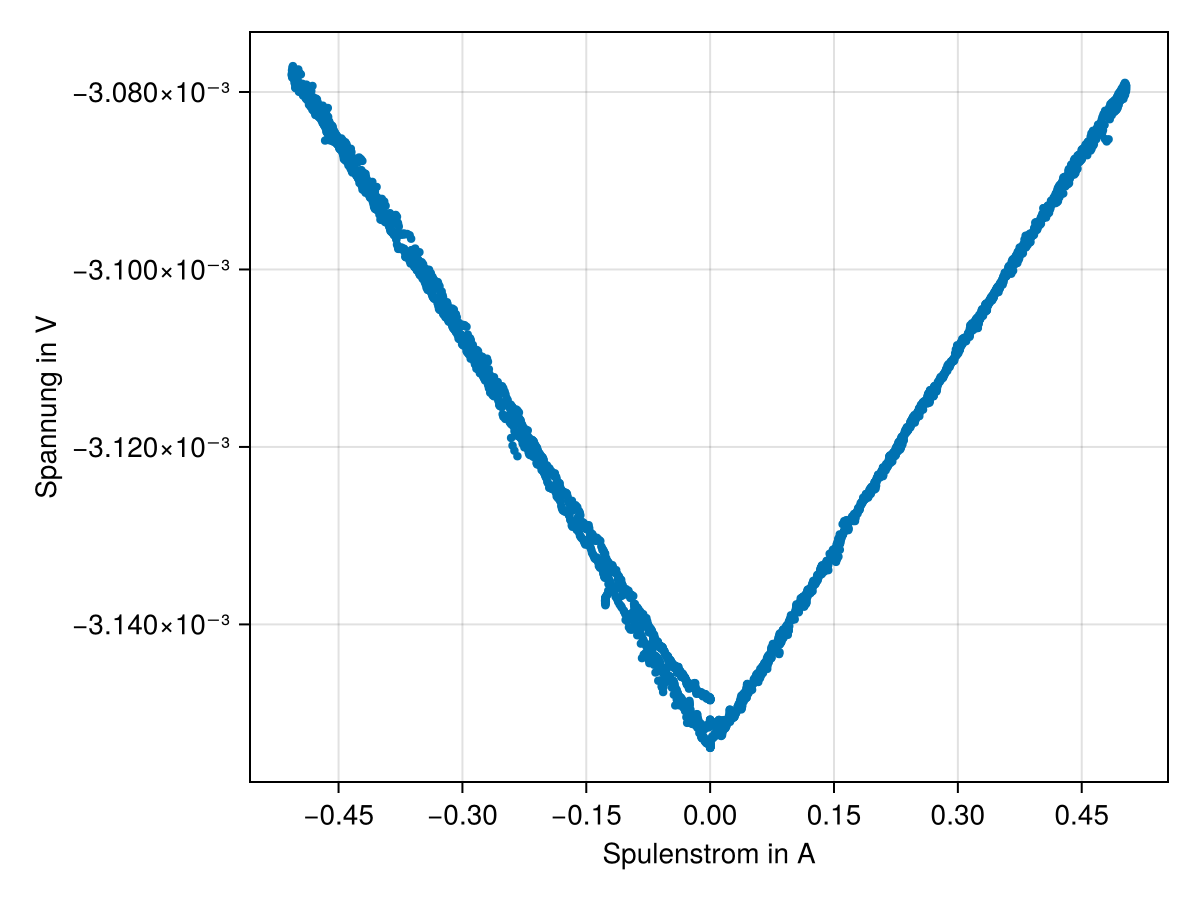

In [8]:
#=Da diese Werte durch das Drehen des Rads des Stromes entstanden sind, werden diese 
ür eine einfachere Auswertung weggenommen=#

mask = y .> -3.2e-3

U = y[mask]
I = x[mask]

fig2 = Figure()
ax = Axis(fig2[1,1], xlabel = "Spulenstrom in A", ylabel ="Spannung in V",
 xticks=LinearTicks(8))

scatter!(ax, I, U, markersize=6)
fig2

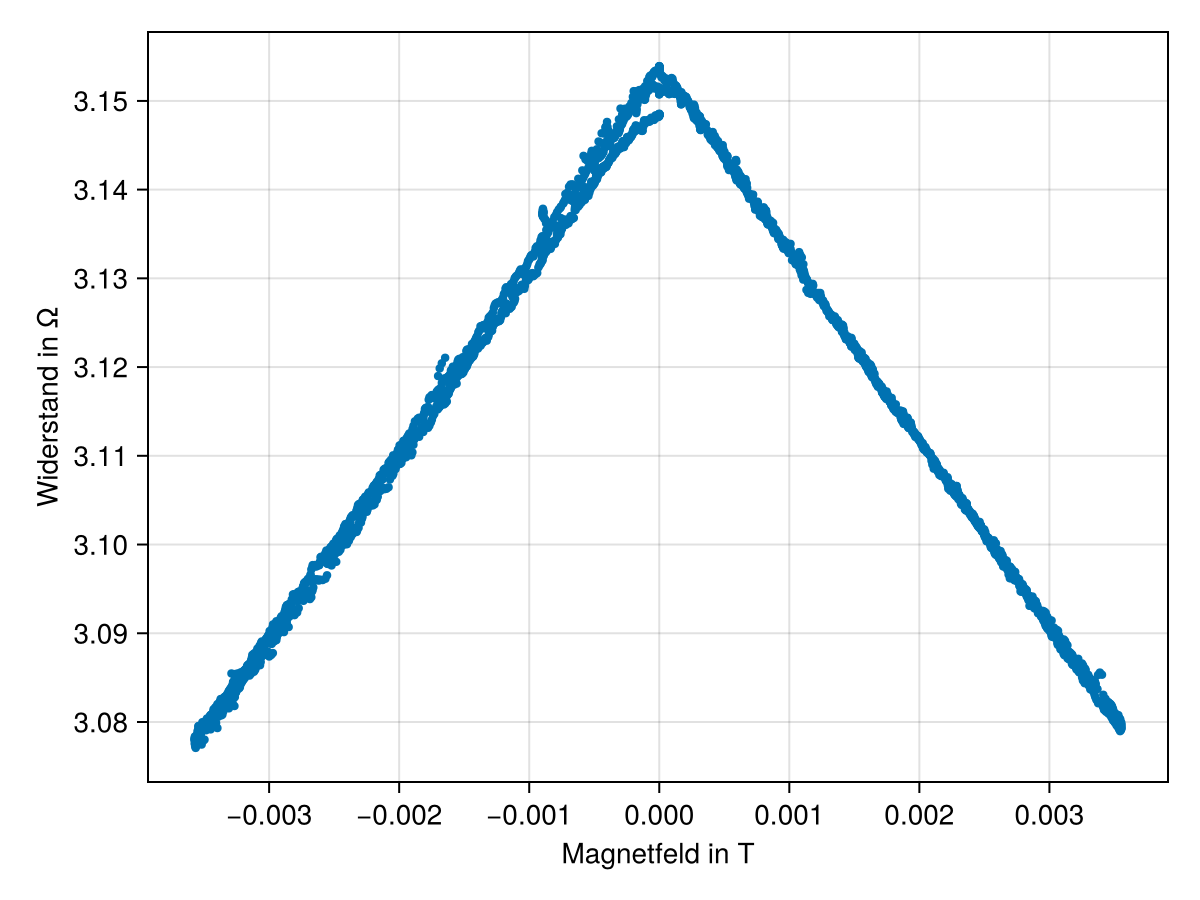

In [21]:
#Berechnen von R und B 

μ0 = 4π*1e-7
N =510 #Mittelwert der beiden N ergebnisse
r = 0.065 #cm to m 
c = (4/5)^(3/2)
I_probe = 1e-3 #in A 

B = I .* (c*μ0*N/r)
R = abs.(U ./ I_probe) 

#Seh hohen einzelwert wegnehm
maskR =  (R .> -800) .&  (R .< 4000)
B_r = B[maskR]
R_r = R[maskR]

fig3 = Figure()
ax = Axis(fig3[1,1], xlabel = "Magnetfeld in T", ylabel ="Widerstand in Ω",
 xticks=LinearTicks(8), yticks=LinearTicks(10))

scatter!(ax, B, R, markersize=6)
fig3

In [25]:
#Bestimmung des GMR-Effekts in Prozent

R_max = maximum(R)
R_min = minimum(R)

GMR = (R_max - R_min)/R_min * 100

println("R_max= $(round(R_max, digits=3)) Ω")
println("R_min=$(round(R_min,digits=3)) Ω")
println("GMR = $(round(GMR, digits=1)) %")

R_max= 3.154 Ω
R_min=3.077 Ω
GMR = 2.5 %


In [26]:
save("Spannung_Strom_para.pdf",fig)
save("Spannung_Strom_angepasst_para.pdf",fig2)
save("R_vs_B_para.pdf",fig3)

CairoMakie.Screen{PDF}
